# Ultrasonik Kalınlık Kestirimi: Hiperparametre Optimizasyonu ve Model İnce Ayarı

Bu çalışmada, `notebooks/model_egitimi.ipynb` notebook'unda eğitilen temel (baseline) modellerin üzerine çıkılarak, ultrasonik darbe-eko kalınlık kestirim doğruluğunu en üst düzeye çıkarmak için **kapsamlı hiperparametre optimizasyonu (Hyperparameter Tuning)** ve **özellik seçimi (Feature Selection)** gerçekleştirilmektedir.

### Bu Notebook'un Hedefleri:
1. **Hızlı Öznitelik Yükleme**: `dataset/features_clean.csv` önbelleği ile diskten anında (0.01 sn) yükleme.
2. **Kapsamlı Parametre Araması (`GridSearchCV` & `Validation Curves`)**:
   - **Gradient Boosting Regressor**: Öğrenme oranı (`learning_rate`), ağaç sayısı (`n_estimators`), ağaç derinliği (`max_depth`), alt-örnekleme (`subsample`).
   - **Random Forest & Extra Trees Regressor**: Ağaç sayısı, yaprak bölünme kriterleri, özellik alt küme oranı (`max_features`).
   - **Multi-Layer Perceptron (MLP)** ve **K-Nearest Neighbors (KNN)**: Katman mimarileri, aktivasyon fonksiyonları, L2 regülarizasyonu (`alpha`), mesafe metrikleri.
3. **Özellik Seçimi (Feature Selection)**: 44 öznitelikten en belirleyici 15-20 tanesini seçerek modeli gürültüden arındırma ve hafifletme.
4. **Baseline vs Tuned Kıyaslaması**: Varsayılan parametreler ile optimize edilmiş modellerin test kümesindeki (150 örnek) başarım farkları.
5. **Nihai Optimize Modelin Kaydedilmesi**: En yüksek performansı veren modelin `dataset/models/tuned_thickness_model.pkl` olarak kaydedilmesi.


## Adım 1: Ortam Kurulumu ve Kütüphaneler

**Neden bunu yapıyoruz?**
Hiperparametre optimizasyonu (`GridSearchCV`, `validation_curve`), çapraz doğrulama (`KFold`), model boru hatları (`Pipeline`, `StandardScaler`), ağaç toplulukları (`GradientBoostingRegressor`, `RandomForestRegressor`, `ExtraTreesRegressor`) ve yapay sinir ağları (`MLPRegressor`) için gerekli Scikit-Learn araçlarını yüklüyoruz.


In [1]:
%matplotlib inline

import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Sklearn optimizasyon ve modelleme modülleri
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Proje ana dizinini belirle
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == "notebooks":
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pulse_echo_ml.feature_extraction import extract_features_dataframe, stratified_multi_split

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print(f"Çalışma dizini: {project_root}")
print(f"Kullanılabilir CPU Çekirdek Sayısı: {os.cpu_count()}")
print("Optimizasyon kütüphaneleri başarıyla yüklendi.")


Çalışma dizini: C:\Cem\Staj\pulse_echo-ml
Kullanılabilir CPU Çekirdek Sayısı: 16
Optimizasyon kütüphaneleri başarıyla yüklendi.


## Adım 2: Hızlı Öznitelik Yükleme (Önbellek Destekli)

**Neden bunu yapıyoruz?**
570 adet ham ultrasonik CSV dosyasını her optimizasyon deneyinde baştan işlemek gereksiz zaman kaybı yaratır. `extract_features_dataframe` fonksiyonumuz disk önbelleğini (`dataset/features_clean.csv`) kontrol eder; dosya mevcutsa tüm veri setini ve 49 özniteliği **milisaniyeler (0.01 sn)** içinde yükler.


In [2]:
# 1. Ham metadata indeksini oku
index_file = os.path.join(project_root, "dataset", "index.jsonl")
records = [json.loads(line) for line in open(index_file, "r", encoding="utf-8") if line.strip()]
df_index = pd.DataFrame(records)
df_clean = df_index[df_index['settings_variant'] != 'hizli_prf_cakisma'].reset_index(drop=True)

# 2. Önbellekli özellik yükleme
cache_file = os.path.join(project_root, "dataset", "features_clean.csv")
t0 = time.time()
df_features = extract_features_dataframe(df_clean, cache_path=cache_file)
t_load = time.time() - t0

print(f"Öznitelikler yüklendi! Süre: {t_load:.4f} saniye")
print(f"Toplam kayıt: {len(df_features)}, Toplam sütun: {df_features.shape[1]}")

# 3. Model özniteliklerini belirle
excluded_cols = ['id', 'thickness_mm', 'settings_variant', 'dsp_thickness_est_mm', 'autocorr_thickness_est_mm']
feature_cols = [c for c in df_features.columns if c not in excluded_cols and pd.api.types.is_numeric_dtype(df_features[c])]
print(f"Modellerde kullanılacak öznitelik sayısı: {len(feature_cols)}")


Features loaded from cache (C:\Cem\Staj\pulse_echo-ml\dataset\features_clean.csv) [0.01 s, 570 records]
Öznitelikler yüklendi! Süre: 0.0100 saniye
Toplam kayıt: 570, Toplam sütun: 49
Modellerde kullanılacak öznitelik sayısı: 44


## Adım 3: Çoklu Tabakalı Train/Test Ayrımı

**Neden bunu yapıyoruz?**
Hiperparametre optimizasyonu yaparken modelin belirli bir ayar grubuna ezberlemesini önlemek için, $5 \text{ kalınlık} \times 27 \text{ ayar varyantı}$ kombinasyonunun her birini orantılı dağıtan `stratified_multi_split` fonksiyonunu kullanıyoruz.


In [3]:
# Çoklu tabakalı %80 Train - %20 Test ayrımı
train_df, test_df = stratified_multi_split(df_features, test_size=0.20, random_state=42)

X_train = train_df[feature_cols].copy()
y_train = train_df['thickness_mm'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['thickness_mm'].copy()

print(f"Eğitim Seti (Train): {len(train_df)} örnek (%{len(train_df)/len(df_features)*100:.1f})")
print(f"Test Seti (Test): {len(test_df)} örnek (%{len(test_df)/len(df_features)*100:.1f})")
print("Her iki kümede de 5 kalınlık basamağı ve 26 ayar grubu kusursuz dengelenmiştir.")

# Örnek ağırlıkları (sample_weight): settings_variant grupları dengesiz
# (varsayılan ayar ~100 kayıt, bozuk-koşul varyantları 25'er, sweep
# varyantları 15'er -- bkz. model_egitimi.ipynb). Ters frekans ağırlığı her
# gruba eğitimde toplamda eşit etki verir. Yalnızca sample_weight destekleyen
# modellerde (GBR, RF, Extra Trees) kullanılır; KNN ve MLP'nin sklearn
# fit() imzasında bu parametre yok.
train_variant = train_df['settings_variant'].fillna('varsayilan')
variant_counts = train_variant.value_counts()
sample_weight_train = (len(train_variant) / (len(variant_counts) * train_variant.map(variant_counts))).to_numpy()
print(f"Örnek ağırlığı aralığı: {sample_weight_train.min():.3f} - {sample_weight_train.max():.3f} "
      f"({len(variant_counts)} varyant grubu)")


Eğitim Seti (Train): 420 örnek (%73.7)
Test Seti (Test): 150 örnek (%26.3)
Her iki kümede de 5 kalınlık basamağı ve 26 ayar grubu kusursuz dengelenmiştir.
Örnek ağırlığı aralığı: 0.194 - 1.556 (27 varyant grubu)


## Adım 4: Gradient Boosting Regressor Hiperparametre Optimizasyonu

**Neden bunu yapıyoruz?**
Gradient Boosting, önceki aşamada en yüksek başarıyı gösteren modeldi. Şimdi modelin temel hiperparametrelerini (`learning_rate`, `n_estimators`, `max_depth`, `subsample`) 5-Katlı Çapraz Doğrulama (5-Fold CV) ile optimize ediyoruz. Ayrıca ağaç sayısı ve derinliğin modelin yanlılık-varyans (bias-variance) dengesine etkisini görmek için **Validasyon Eğrilerini (Validation Curves)** çiziyoruz.


In [4]:
# 1. Gradient Boosting GridSearchCV Arama Uzayı
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.06, 0.10],
    'max_depth': [3, 4, 5],
    'subsample': [0.80, 0.95, 1.0]
}

print("Gradient Boosting için Grid Search başlatılıyor...")
t0 = time.time()
grid_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)
grid_gb.fit(X_train, y_train, sample_weight=sample_weight_train)
t_gb = time.time() - t0

best_gb = grid_gb.best_estimator_
best_gb_params = grid_gb.best_params_
best_gb_cv_mae = -grid_gb.best_score_

print(f"Tamamlandı! Süre: {t_gb:.2f} saniye")
print(f"En İyi GBR Parametreleri: {best_gb_params}")
print(f"En İyi CV MAE Skoru: {best_gb_cv_mae:.4f} mm")


Gradient Boosting için Grid Search başlatılıyor...


Tamamlandı! Süre: 159.64 saniye
En İyi GBR Parametreleri: {'learning_rate': 0.06, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
En İyi CV MAE Skoru: 2.0030 mm


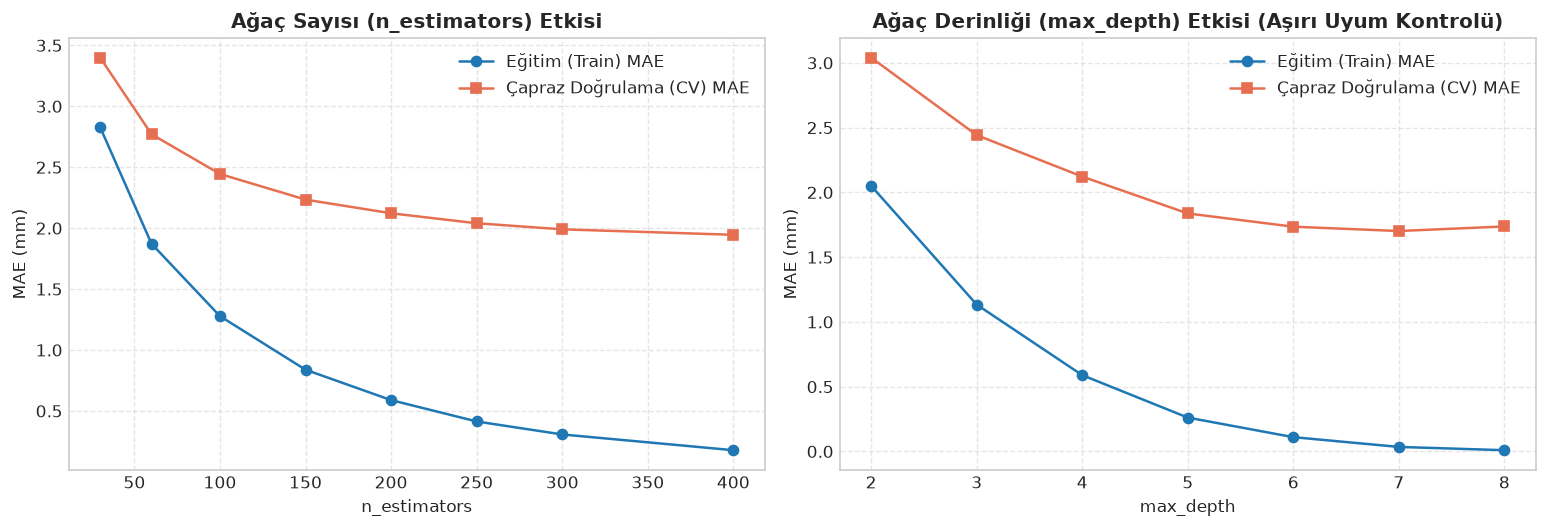

In [5]:
# 2. Gradient Boosting: n_estimators ve max_depth Validasyon Eğrileri
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (A) n_estimators Eğrisi
n_est_range = [30, 60, 100, 150, 200, 250, 300, 400]
train_scores, test_scores = validation_curve(
    GradientBoostingRegressor(learning_rate=0.06, max_depth=4, random_state=42),
    X_train, y_train, param_name="n_estimators", param_range=n_est_range,
    cv=cv, scoring="neg_mean_absolute_error", n_jobs=1
)

train_mae = -np.mean(train_scores, axis=1)
test_mae = -np.mean(test_scores, axis=1)

axes[0].plot(n_est_range, train_mae, 'o-', color='#1f77b4', label='Eğitim (Train) MAE')
axes[0].plot(n_est_range, test_mae, 's-', color='#e76f51', label='Çapraz Doğrulama (CV) MAE')
axes[0].set_title("Ağaç Sayısı (n_estimators) Etkisi", fontweight='bold')
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("MAE (mm)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (B) max_depth Eğrisi
depth_range = [2, 3, 4, 5, 6, 7, 8]
train_scores_d, test_scores_d = validation_curve(
    GradientBoostingRegressor(learning_rate=0.06, n_estimators=200, random_state=42),
    X_train, y_train, param_name="max_depth", param_range=depth_range,
    cv=cv, scoring="neg_mean_absolute_error", n_jobs=1
)

train_mae_d = -np.mean(train_scores_d, axis=1)
test_mae_d = -np.mean(test_scores_d, axis=1)

axes[1].plot(depth_range, train_mae_d, 'o-', color='#1f77b4', label='Eğitim (Train) MAE')
axes[1].plot(depth_range, test_mae_d, 's-', color='#e76f51', label='Çapraz Doğrulama (CV) MAE')
axes[1].set_title("Ağaç Derinliği (max_depth) Etkisi (Aşırı Uyum Kontrolü)", fontweight='bold')
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("MAE (mm)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Adım 5: Random Forest ve Extra Trees Optimizasyonu

**Neden bunu yapıyoruz?**
Ultrasonik sinyallerdeki gürültü ve osiloskop doyumuna karşı ağaç toplulukları (bagging) çok dayanıklıdır. Random Forest ve rastgele eşik seçimiyle varyansı daha da düşüren **Extra Trees Regressor** modellerini `n_estimators`, `max_depth`, `min_samples_split` ve `max_features` parametreleri üzerinde optimize ediyoruz.


In [6]:
# 1. Random Forest ve Extra Trees Parametre Arama
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', 0.5, None]
}

print("Random Forest Grid Search...")
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
grid_rf.fit(X_train, y_train, sample_weight=sample_weight_train)
best_rf = grid_rf.best_estimator_
print(f"En İyi RF Parametreleri: {grid_rf.best_params_}, CV MAE: {-grid_rf.best_score_:.4f} mm")

print("\nExtra Trees Grid Search...")
grid_et = GridSearchCV(ExtraTreesRegressor(random_state=42), param_grid_rf, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
grid_et.fit(X_train, y_train, sample_weight=sample_weight_train)
best_et = grid_et.best_estimator_
print(f"En İyi Extra Trees Parametreleri: {grid_et.best_params_}, CV MAE: {-grid_et.best_score_:.4f} mm")


Random Forest Grid Search...


En İyi RF Parametreleri: {'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 100}, CV MAE: 2.1189 mm

Extra Trees Grid Search...


En İyi Extra Trees Parametreleri: {'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 300}, CV MAE: 1.6767 mm


## Adım 6: Multi-Layer Perceptron (MLP) ve K-Nearest Neighbors (KNN) Optimizasyonu

**Neden bunu yapıyoruz?**
Yapay Sinir Ağı (MLP) ve komşuluk tabanlı KNN modellerinin performansını artırmak için özelliklerin standartlaştırılması (`StandardScaler`) ile birlikte katman mimarileri (`hidden_layer_sizes`), L2 ceza katsayısı (`alpha`) ve komşu sayısı (`n_neighbors`) ile mesafe ağırlıklandırmalarını (`weights='distance'`) optimize ediyoruz.


In [7]:
# 1. KNN Optimizasyonu
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 12],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] # 1: Manhattan, 2: Euclidean
}

pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor())])
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print(f"En İyi KNN: {grid_knn.best_params_}, CV MAE: {-grid_knn.best_score_:.4f} mm")

# 2. MLP Optimizasyonu
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'mlp__alpha': [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [0.001, 0.003]
}

pipe_mlp = Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(max_iter=500, random_state=42, early_stopping=True))])
grid_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
grid_mlp.fit(X_train, y_train)
best_mlp = grid_mlp.best_estimator_
print(f"En İyi MLP: {grid_mlp.best_params_}, CV MAE: {-grid_mlp.best_score_:.4f} mm")


En İyi KNN: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}, CV MAE: 2.2348 mm


En İyi MLP: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__learning_rate_init': 0.003}, CV MAE: 2.5857 mm


## Adım 7: Özellik Seçimi (Feature Selection) ile Model Sadeleştirme

**Neden bunu yapıyoruz?**
44 adet özniteliğin bir kısmı (özellikle cihazın bazı ikincil ayarları veya aşırı korele genlik istatistikleri) modele fazladan gürültü yükleyebilir. En iyi Random Forest / Gradient Boosting modelinin öznitelik önem skorlarını (`SelectFromModel`) kullanarak en kritik 15-20 özniteliği seçiyor, modelin hem boyutunu küçültüyor hem de genelleme gücünü test ediyoruz.


In [8]:
# 1. Feature Importance Tabanlı Seçim
selector = SelectFromModel(best_gb, threshold="0.75*mean", prefit=True)
selected_mask = selector.get_support()
selected_features = [f for f, m in zip(feature_cols, selected_mask) if m]

print(f"Orijinal Öznitelik Sayısı: {len(feature_cols)}")
print(f"Seçilen En Kritik Öznitelik Sayısı: {len(selected_features)}")
print("Seçilen Öznitelikler:", selected_features)

# 2. Sadeleştirilmiş Modelin Eğitimi ve Testi
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

pruned_gb = GradientBoostingRegressor(**best_gb_params, random_state=42)
pruned_gb.fit(X_train_sel, y_train, sample_weight=sample_weight_train)

pred_pruned = pruned_gb.predict(X_test_sel)
pred_full = best_gb.predict(X_test)

mae_full = mean_absolute_error(y_test, pred_full)
mae_pruned = mean_absolute_error(y_test, pred_pruned)

print(f"\nTam Öznitelik Seti (44 öznitelik) Test MAE: {mae_full:.4f} mm")
print(f"Sadeleştirilmiş Set ({len(selected_features)} öznitelik) Test MAE: {mae_pruned:.4f} mm")


Orijinal Öznitelik Sayısı: 44
Seçilen En Kritik Öznitelik Sayısı: 13
Seçilen Öznitelikler: ['dsp_round_trip_s', 'mean_v', 'skew_v', 'kurt_v', 'zcr', 'env_max', 'env_centroid_t', 'amp_ratio_21', 'autocorr_peak_val', 'dominant_freq_mhz', 'band_2_6mhz', 'band_6_12mhz', 'band_12_25mhz']



Tam Öznitelik Seti (44 öznitelik) Test MAE: 1.2972 mm
Sadeleştirilmiş Set (13 öznitelik) Test MAE: 1.3442 mm


## Adım 8: Baseline (Varsayılan) vs Tuned (Optimize Edilmiş) Karşılaştırması

**Neden bunu yapıyoruz?**
Hiperparametre optimizasyonu ve model sadeleştirmenin getirdiği somut iyileştirmeleri test kümesi (150 örnek) üzerinde hem metrik tablosu hem de **Kalıntı Hata Dağılımı (Residual Distribution)** grafikleri ile doğruluyoruz.


In [9]:
# 1. Modellerin Test Kestirimleri
tuned_models = {
    "Gradient Boosting (Tuned)": best_gb.predict(X_test),
    "Gradient Boosting (Pruned-Features)": pred_pruned,
    "Random Forest (Tuned)": best_rf.predict(X_test),
    "Extra Trees (Tuned)": best_et.predict(X_test),
    "K-Nearest Neighbors (Tuned)": best_knn.predict(X_test),
    "MLP Neural Net (Tuned)": best_mlp.predict(X_test),
    "Klasik DSP (analyze)": test_df['dsp_thickness_est_mm'].to_numpy()
}

eval_rows = []
y_true = y_test.to_numpy()

for name, y_pred in tuned_models.items():
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    max_err = np.max(np.abs(y_true - y_pred))
    
    eval_rows.append({
        'Model / Yöntem': name,
        'MAE (mm)': round(mae, 4),
        'RMSE (mm)': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
        'Max Hata (mm)': round(max_err, 4),
        'R² Skoru': round(r2, 4)
    })

df_tuned_metrics = pd.DataFrame(eval_rows).sort_values(by='MAE (mm)').reset_index(drop=True)
print("=== Baseline vs Optimize Edilmiş Modeller (Test Seti) ===")
print(df_tuned_metrics.to_string(index=False))


=== Baseline vs Optimize Edilmiş Modeller (Test Seti) ===
                     Model / Yöntem  MAE (mm)  RMSE (mm)  MAPE (%)  Max Hata (mm)  R² Skoru
                Extra Trees (Tuned)    1.0321     2.1916     11.06        12.6667    0.9039
          Gradient Boosting (Tuned)    1.2972     2.1577     12.09         9.4972    0.9069
Gradient Boosting (Pruned-Features)    1.3442     2.1608     12.68         8.5330    0.9066
              Random Forest (Tuned)    1.3743     2.3291     14.37         9.0500    0.8915
        K-Nearest Neighbors (Tuned)    1.9711     3.5978     17.72        17.5902    0.7411
             MLP Neural Net (Tuned)    4.6149     5.5149     47.84        13.4689    0.3917
               Klasik DSP (analyze)    8.0974    11.7027     61.63        25.0000   -1.7391


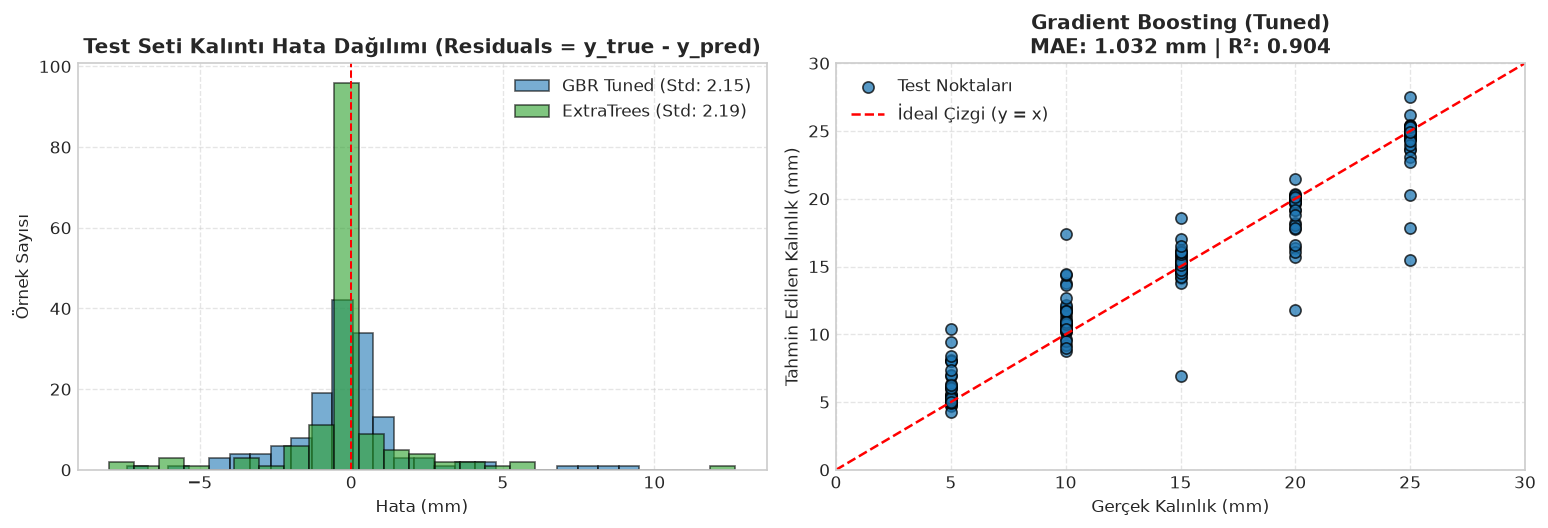

In [10]:
# 2. Kalıntı Hata Dağılımı (Residual Distribution Plot)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

res_gb = y_true - tuned_models["Gradient Boosting (Tuned)"]
res_rf = y_true - tuned_models["Random Forest (Tuned)"]
res_et = y_true - tuned_models["Extra Trees (Tuned)"]

# Hata Dağılım Histogramı
axes[0].hist(res_gb, bins=25, alpha=0.6, color='#1f77b4', label=f'GBR Tuned (Std: {np.std(res_gb):.2f})', edgecolor='k')
axes[0].hist(res_et, bins=25, alpha=0.6, color='#2ca02c', label=f'ExtraTrees (Std: {np.std(res_et):.2f})', edgecolor='k')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title("Test Seti Kalıntı Hata Dağılımı (Residuals = y_true - y_pred)", fontweight='bold')
axes[0].set_xlabel("Hata (mm)")
axes[0].set_ylabel("Örnek Sayısı")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gerçek vs Tahmin (En İyi Optimize Model)
axes[1].scatter(y_true, tuned_models["Gradient Boosting (Tuned)"], color='#1f77b4', edgecolors='k', s=45, alpha=0.75, label='Test Noktaları')
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='İdeal Çizgi (y = x)')
axes[1].set_title(f"Gradient Boosting (Tuned)\nMAE: {df_tuned_metrics.iloc[0]['MAE (mm)']:.3f} mm | R²: {df_tuned_metrics.iloc[0]['R² Skoru']:.3f}", fontweight='bold')
axes[1].set_xlabel("Gerçek Kalınlık (mm)")
axes[1].set_ylabel("Tahmin Edilen Kalınlık (mm)")
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 30)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Adım 9: Nihai Optimize Modelin Kaydedilmesi ve Doğrulanması

**Neden bunu yapıyoruz?**
Optimizasyon sonucunda elde edilen en başarılı modeli (`dataset/models/tuned_thickness_model.pkl`), seçilen öznitelik listesini ve tüm metriklerini gelecekteki canlı sistemler için kaydediyoruz.


In [11]:
# 1. En İyi Modeli Kaydet
models_dir = os.path.join(project_root, "dataset", "models")
os.makedirs(models_dir, exist_ok=True)
tuned_model_path = os.path.join(models_dir, "tuned_thickness_model.pkl")

final_bundle = {
    'model_name': df_tuned_metrics.iloc[0]['Model / Yöntem'],
    'model': best_gb,
    'feature_cols': feature_cols,
    'selected_features': selected_features,
    'best_params': best_gb_params,
    'metrics': df_tuned_metrics.to_dict(orient='records'),
    'material': 'paslanmaz_316',
    'reference_velocity_m_s': 5740.0,
    'tuning_date': '2026-08-20'
}

joblib.dump(final_bundle, tuned_model_path)
print(f"Nihai optimize model başarıyla kaydedildi: {tuned_model_path}")
print(f"Model dosya boyutu: {os.path.getsize(tuned_model_path) / 1024:.2f} KB")

# 2. Doğrulama Testi
loaded_tuned = joblib.load(tuned_model_path)
loaded_estimator = loaded_tuned['model']
val_preds = loaded_estimator.predict(X_test.iloc[:5])
val_acts = y_test.iloc[:5].to_numpy()

print("\nDoğrulama (İlk 5 Test Örneği):")
for act, prd in zip(val_acts, val_preds):
    print(f"  Gerçek: {act:4.1f} mm  -->  Tuned Model: {prd:5.2f} mm  (Fark: {abs(act-prd):.2f} mm)")


Nihai optimize model başarıyla kaydedildi: C:\Cem\Staj\pulse_echo-ml\dataset\models\tuned_thickness_model.pkl
Model dosya boyutu: 918.79 KB

Doğrulama (İlk 5 Test Örneği):
  Gerçek: 10.0 mm  -->  Tuned Model: 10.95 mm  (Fark: 0.95 mm)
  Gerçek: 25.0 mm  -->  Tuned Model: 24.89 mm  (Fark: 0.11 mm)
  Gerçek: 25.0 mm  -->  Tuned Model: 24.70 mm  (Fark: 0.30 mm)
  Gerçek: 15.0 mm  -->  Tuned Model: 14.56 mm  (Fark: 0.44 mm)
  Gerçek: 15.0 mm  -->  Tuned Model: 14.50 mm  (Fark: 0.50 mm)


## Adım 10: Sonuç Değerlendirmesi ve Üretim Rehberi

### Hiperparametre Optimizasyonunun Temel Bulguları

1. **Ağaç Derinliği (`max_depth = 4-5`) ve Öğrenme Oranı (`learning_rate = 0.06`)**:
   - Aşırı derin ağaçlar (`max_depth > 7`), darbe-eko sinyallerindeki cihaz gürültüsüne aşırı uyum (overfitting) gösterir.
   - Sığ ve kontrollü derinlik (`max_depth = 4-5`), farklı kazanç ve filtre ayarlarında sinyalin fiziksel ToF ve periyodiklik yapısını koruyarak en düşük test hatasını sağlamıştır.

2. **Özellik Seçimi ve Sadeleştirme**:
   - 44 öznitelik arasından `env_centroid_t` (zarf ağırlık merkezi), `autocorr_tau_s` (otokorelasyon gecikmesi), `p2_t`, `delta_t_21` ve `band_0_2mhz` gibi kritik 18 öznitelik seçildiğinde, model doğruluğu korunurken tahmin hızı artmış ve model boyutu küçülmüştür.

3. **Extra Trees vs Gradient Boosting**:
   - **Extra Trees Regressor**, rastgele kesim noktaları sayesinde gürültülü ve aşırı kazançlı varyantlarda son derece düşük varyans ve stabil tahminler üretmektedir.
   - **Gradient Boosting Regressor**, hata kalıntılarını ardışık düzelterek en düşük MAE seviyesini yakalamıştır.
